In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from drs4_parser.parser import event_stream, read_first_n, file_properties
from drs4_parser.parser import print_file_properties
from drs4_parser.events_filter.coincidence import file_coincidence_parser, event_coincidence_filter
from drs4_parser.time_analysis import cfd_linear, cfd_analog_time
from drs4_parser.pals import good_event, read_lifetime

from drs4_parser.energy_analysis.baseline import baseline_estimation
from drs4_parser.energy_analysis.pulse_height import pulse_height_3pts_parabolic, pulse_height_robust

In [19]:
# --------- CONFIG ---------
# you can read xml files using 
bin_file = "F:/Data/lifetime/drs4_bin.dat"
max_events = 1000
channels = file_properties(bin_file).channels[1:]
BINS_IN_WAVEFORM = 1024
# --------------------------


In [20]:
print_file_properties(bin_file)

DRS4 binary
  board serial    : 2580
  channels        : 3 (CH2, CH3, CH4)
  samples / event : 1024
  header bytes    : 12312
  events          : 10000
  event size      : 6.1 KB
  file size       : 59.14 MB


streaming events using a generator

In [22]:
es = event_stream(bin_file)
first_event = next(es)
first_event

{'CH2': (array([0.0000000e+00, 1.2755626e-01, 3.8724211e-01, ..., 1.9932733e+02,
         1.9956786e+02, 1.9973201e+02], dtype=float32),
  array([-5.806059 , -5.6076946, -5.4093304, ..., -4.1123033, -3.2120347,
         -3.5019517], dtype=float32)),
 'CH3': (array([0.0000000e+00, 1.5696038e-01, 4.0886474e-01, ..., 1.9933873e+02,
         1.9959497e+02, 1.9974867e+02], dtype=float32),
  array([-2.8000176, -3.6087632, -4.4022202, ..., -8.613706 , -7.713437 ,
         -7.1030855], dtype=float32)),
 'CH4': (array([0.0000000e+00, 1.3363425e-01, 3.9373231e-01, ..., 1.9932094e+02,
         1.9959973e+02, 1.9974466e+02], dtype=float32),
  array([-3.6087632, -3.913939 , -4.203856 , ..., -7.4082613, -6.4011517,
         -6.6147747], dtype=float32))}

In [102]:
first_event_ch1 = xr.DataArray(first_event[channels[0]][1], coords={'time':first_event['CH3'][0]})
first_event_ch2 = xr.DataArray(first_event[channels[1]][1], coords={'time':first_event['CH4'][0]})

as can be seen the first event is a coincidence event

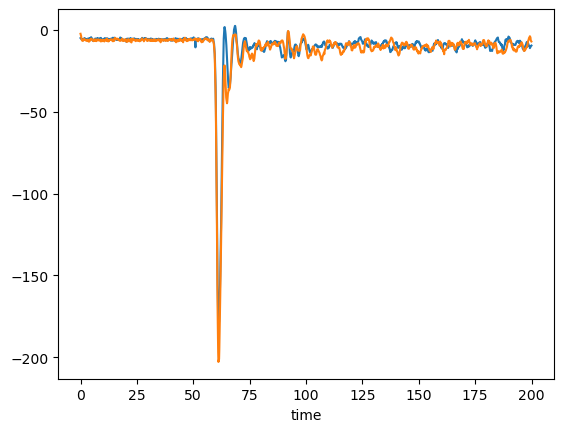

In [103]:
first_event_ch1.plot()
first_event_ch2.plot()

check if they're coincidence or not

In [25]:
event_coincidence_filter(event=first_event, channels=channels,thresholds=(-75, -85))

False

look for first coincidence

In [26]:
es = event_stream(bin_file)
for events in es:
    if event_coincidence_filter(event=events, channels=channels,thresholds=(-75, -85)):
        coin_event_ch1 = xr.DataArray(events['CH3'][1], coords={'time':first_event['CH3'][0]})
        coin_event_ch2 = xr.DataArray(events['CH4'][1], coords={'time':first_event['CH4'][0]})
        break

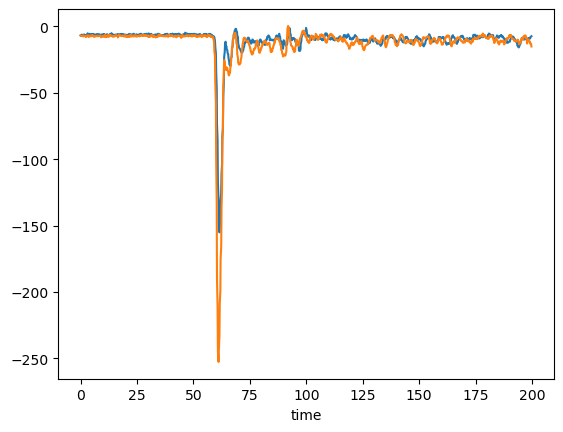

In [89]:
coin_event_ch1.plot()
coin_event_ch2.plot()

cfd

In [106]:
t, v = first_event[channels[1]]

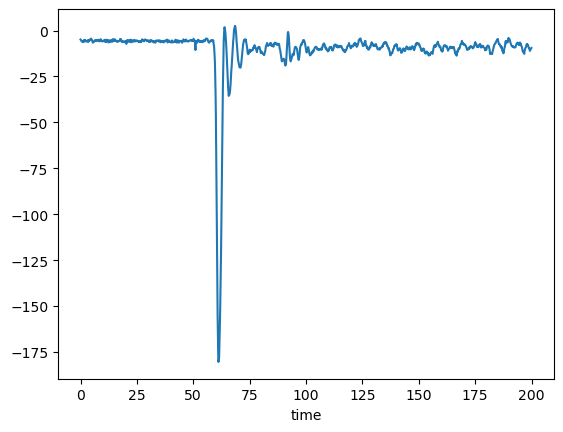

In [107]:
first_event_ch1.plot()

In [108]:
from lifetime_parser.time_analysis import cfd_analog_time
fraction = 0.3
delay_time = 0.5844

t1= cfd_linear(t,v,fraction=fraction, window=1)
t2= cfd_analog_time(t,v,fraction=fraction, delay_time=delay_time)


t1, t2

(60.09169214750913, 60.28665752169908)

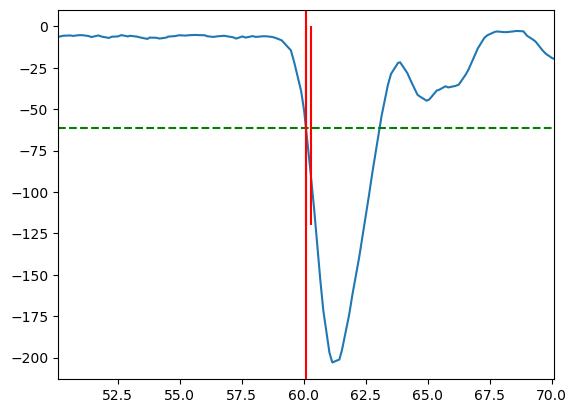

In [109]:
v_min = pulse_height_3pts_parabolic(t, v)

plt.plot(t, v)
plt.vlines(x=t1, ymax=0, ymin=-120, color='red')
plt.vlines(x=t2, ymax=0, ymin=-120, color='red')

plt.xlim([t1-10,t1+10])
plt.axhline(v_min*fraction, color="green", linestyle="--")
plt.axvline(t1, color="red")